<a href="https://colab.research.google.com/github/AlexisArancibia/AST332-Machine_Learning/blob/main/Semana2_Modelo_Linea_Recta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inferencia estadística vs Aprendizaje de máquinas

### Parte 1: Ajuste de recta

(Adaptado de  Viviana Acquaviva (2023))

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
#parámetros para generar figuras de alta calidad
font = {'size'   : 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

Generaremos datos que sigan una relación lineal (con ruido) y usaremos una grilla para encontrar el mejor ajuste, sin y con considerar incertezas

In [ ]:
np.random.seed(16) #semilla fija para reproducibilidad

x = np.arange(10)

y = 2*x + 5 + np.random.randn(10) #generamos datos con scatter gausiano

Podemos considerar que los datos corresponden al movimiento de un auto con rapidez constante, donde $x$ es tiempo (en segundos) e $y$ es distancia (en metros)

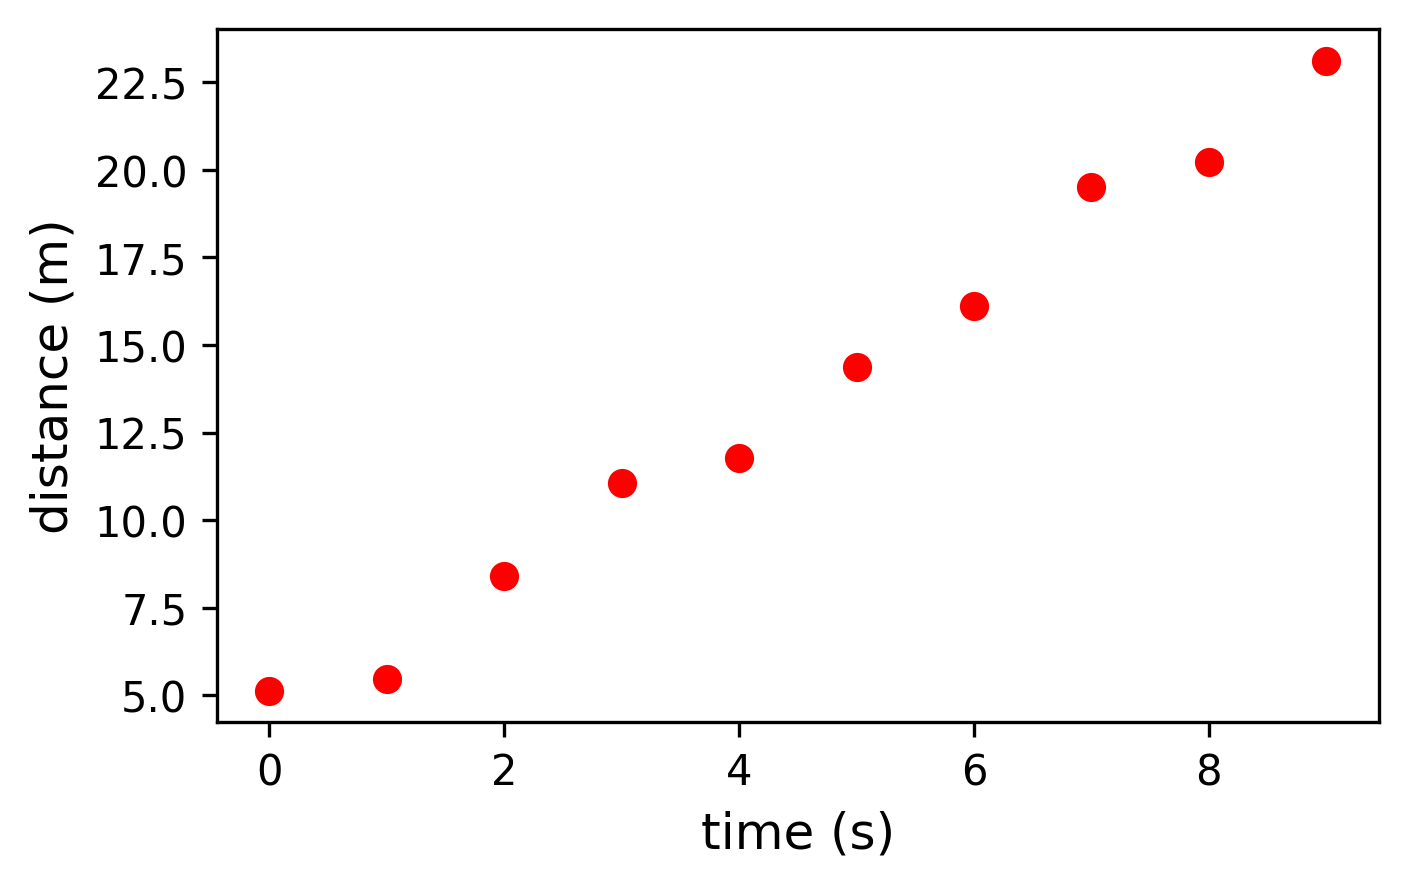

In [ ]:
plt.figure(figsize=(5,3)) #
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [ ]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
y = np.round(y,1) #redondeamos los datos

Suponga que a partir de esos datos debe ser capaz de decir la distancia a la que estará el auto cuando $t=12$ s. ¿Cómo podemos resolver el problema?

### Inferencia

Ya sabemos que la relación entre distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Este modelo tienen dos parámetros: $d_0$ u $v$. Necesitamos encontrar estos parámetros para poder usar el modelo y determinar $d(t=12 s)$.


¿Cómo haría esto?




Explique con palabras:

Para encontrar los valores de los parametros  $d_0$ y  $v$, haría un ajuste a travez del comando polyfit, el cual minimiza el error cuadrático, y luego evaluaría $t= 12s$ en la ecuación obtenida.   

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Encuentre los parámetros de la mejor recta para los datos dados

In [ ]:
#Codigo aca!

modelo=np.polyfit(x,y,1)
print('v= 'f'{modelo[0]:.2f}','d0= 'f'{modelo[1]:.2f}')
v=modelo[0]
d0=modelo[1]
d=d0+v*12
print('d(t=12)= 'f'{d:.2f}')

v= 2.05 d0= 4.30
d(t=12)= 28.88


**Cuáles son los valores de pendiente m e intercepto b encontrado? Con este modelo, cuánto es $d(t=12s)$?**

- **bestm**: 2.05
- **bestb**: 4.30
- **d(t=12)**: 28.88

In [ ]:
bestm=v
bestb=d0

Graficamos el mejor ajuste con los datos

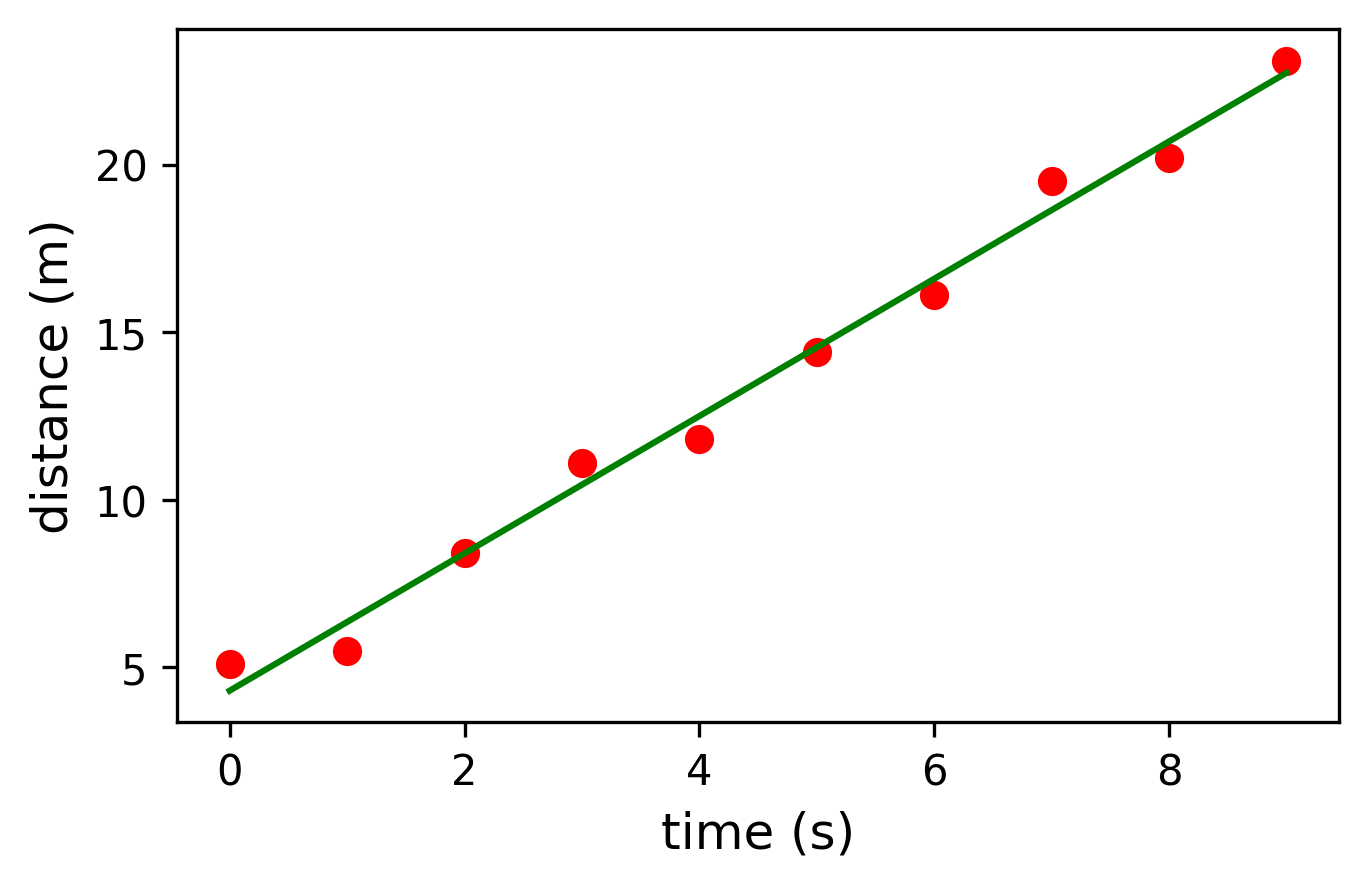

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'g'); #grafique la recta con los mejores parámetros

Y si agregamos incerteza en la medición de distancias?

In [ ]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [ ]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

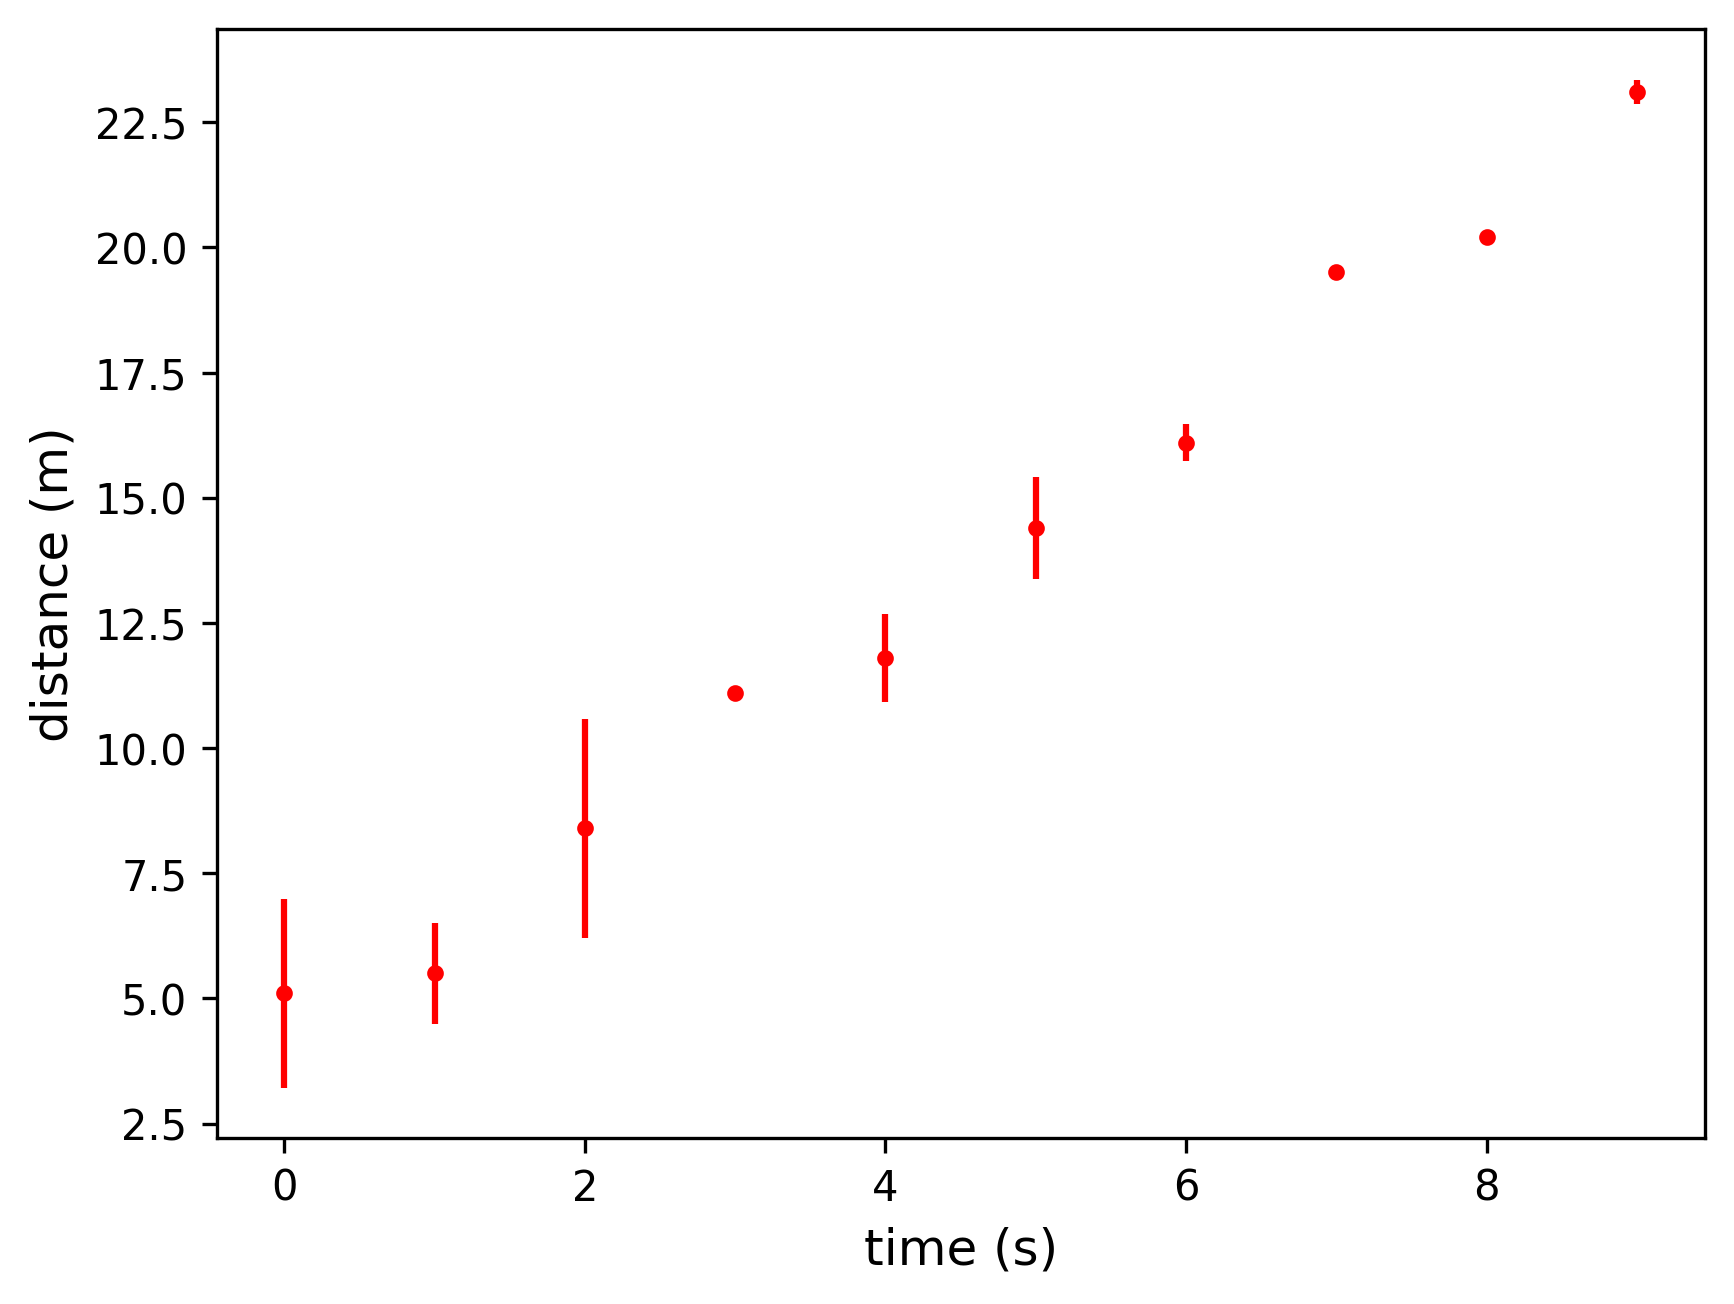

In [ ]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Encuentre los parámetros de la mejor recta cuando agregamos incertezas

In [ ]:
pesos = 1 / dy
modelo_w=np.polyfit(x,y,1,w=pesos)
print('v= 'f'{modelo_w[0]:.2f}','d0= 'f'{modelo_w[1]:.2f}')
vw=modelo_w[0]
d0w=modelo_w[1]

v= 1.82 d0= 5.64


In [ ]:
bestb_werr = d0w
bestm_werr = vw

Graficamos los datos con incertezas y el nuevo ajuste

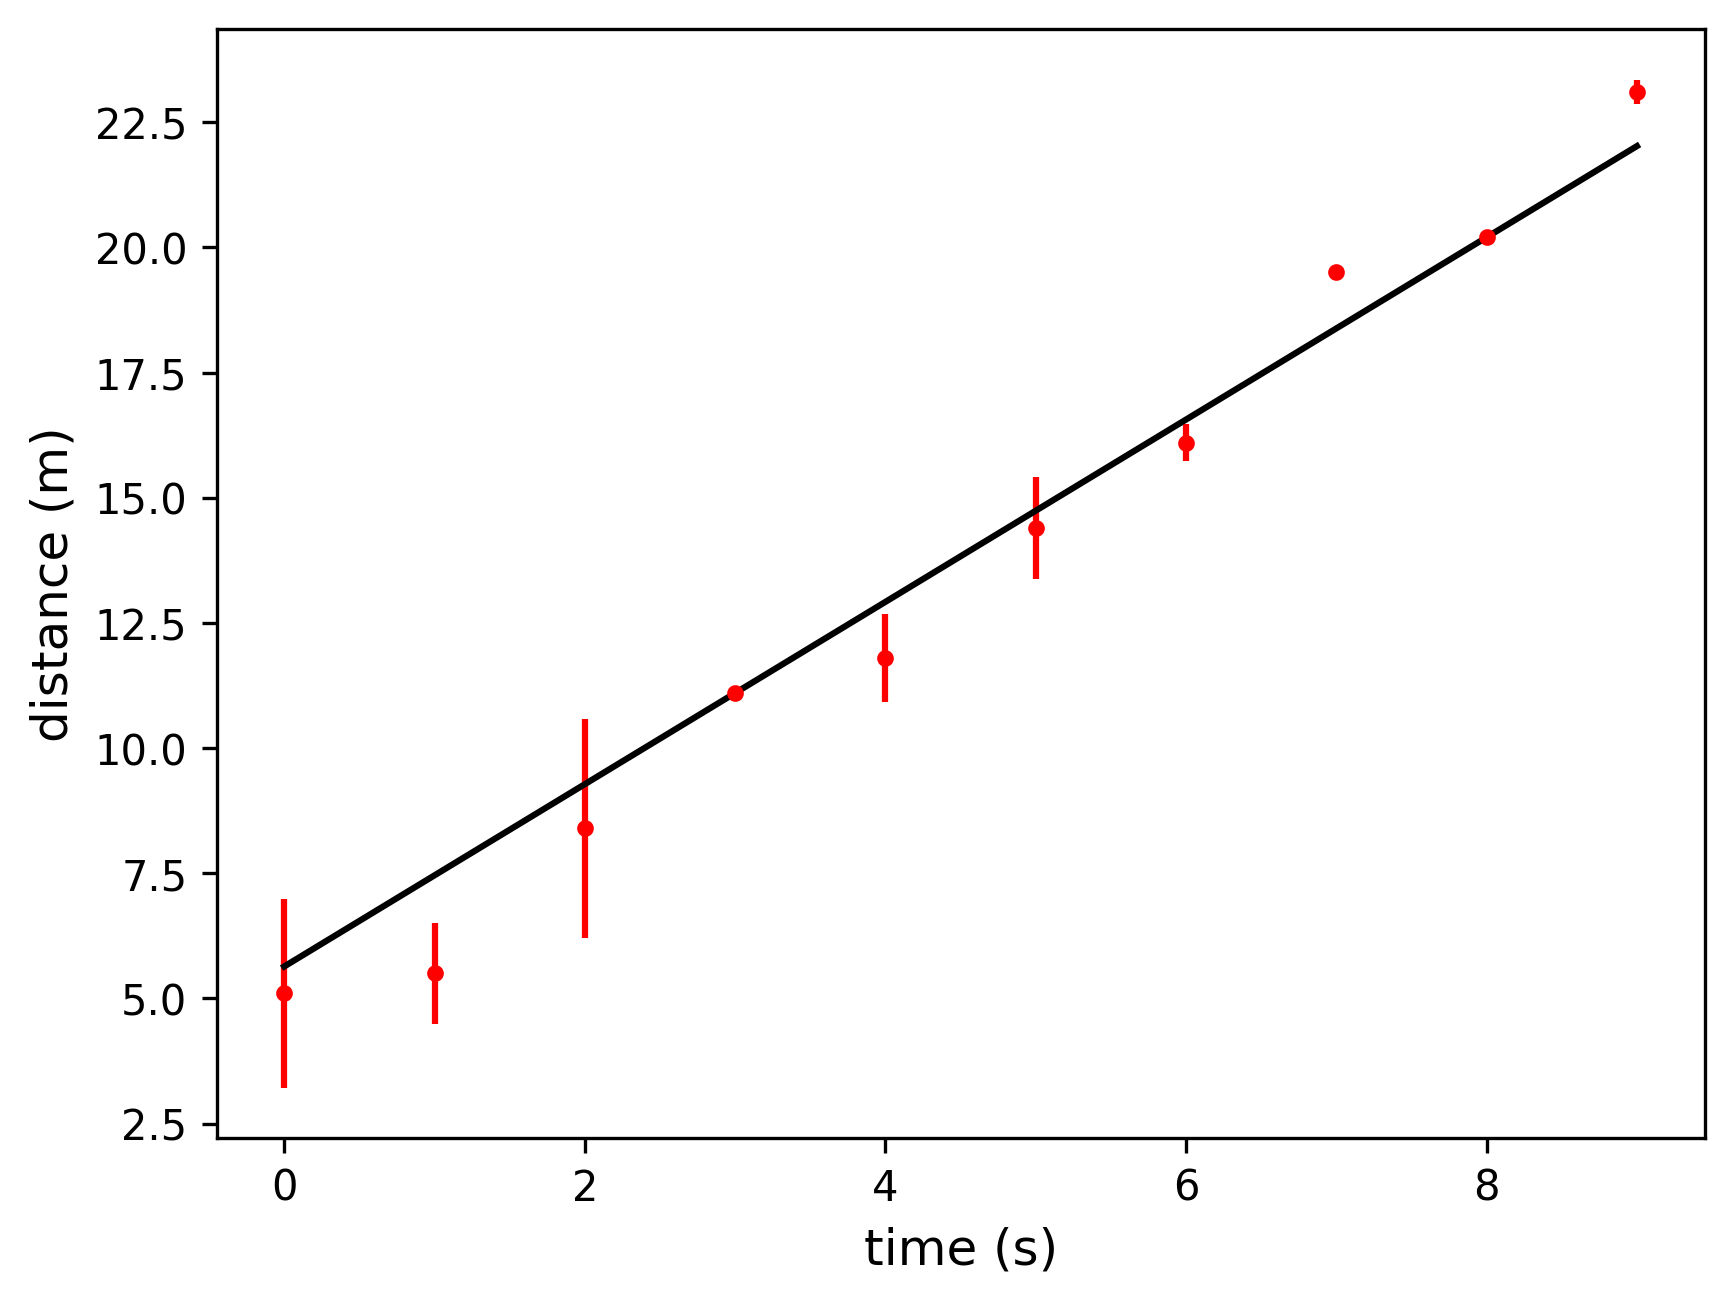

In [ ]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'black') #agregue sus parámetros

Comparemos ambos modelos

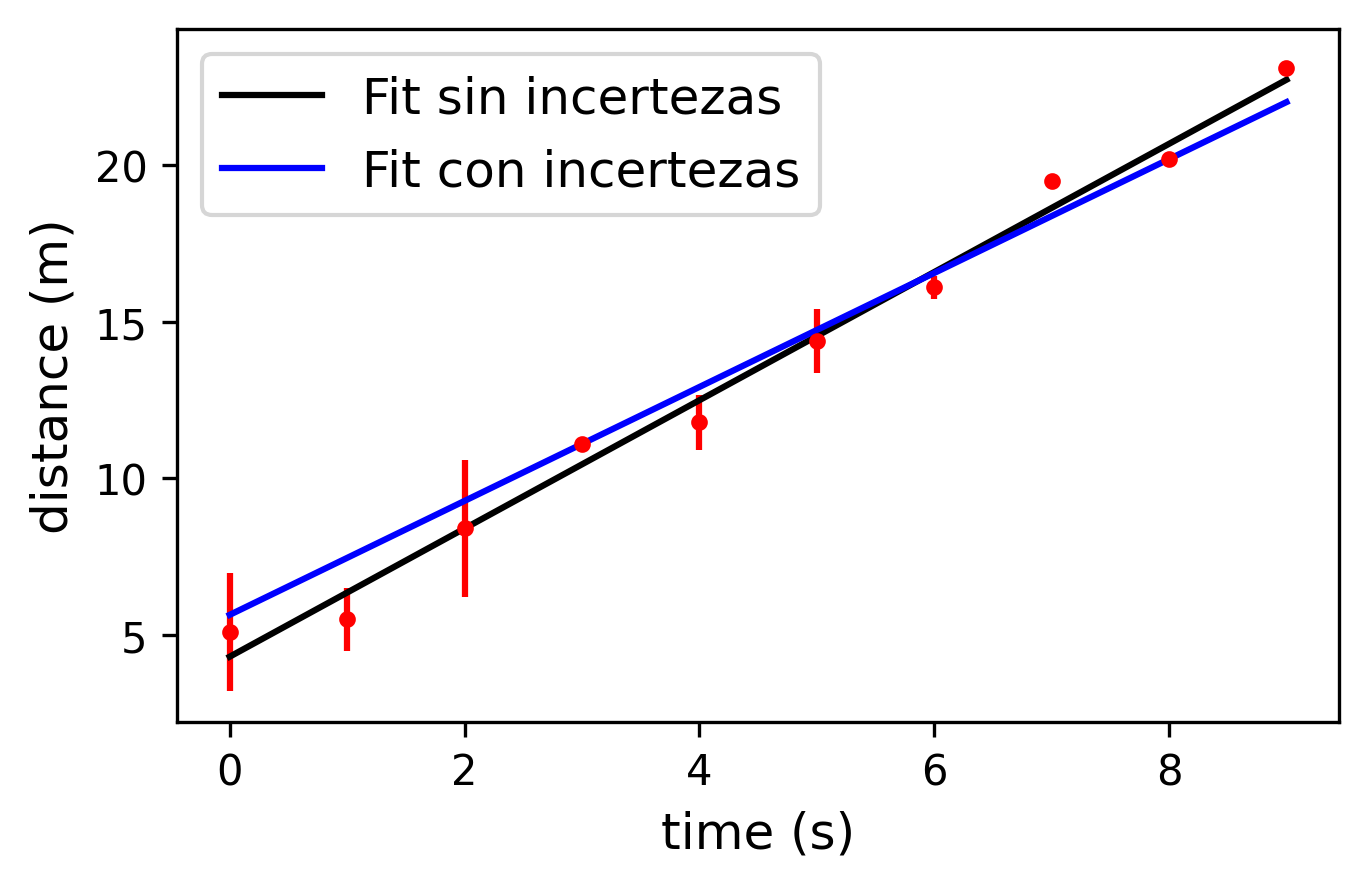

In [ ]:
plt.figure(figsize=(5,3))

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')

plt.plot(x, bestb + bestm * x, c = 'black', label = 'Fit sin incertezas')

plt.plot(x, bestb_werr + bestm_werr * x, c = 'b', label = 'Fit con incertezas')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend()


**Pregunta: ¿Tiene sentido ese cambio?**

Si tiene sentido, ya que al agregarle error a los datos, se da la necesidad de ocupar el peso para el cálculo de los parámetros, haciendo que la recta sea más propensa a pasar directamente por los puntos que presentan bajo error (Esto se debe a que el peso se calcula como 1/$\sigma$).

### Parte 2: Machine Learning

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

#### Importamos de la librería Sci-kit learn los modelos ya implementados y usaremos funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook

In [ ]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión
from sklearn.linear_model import LinearRegression #modelo de regresión lineal
from sklearn.model_selection import train_test_split  #para dividir los datos

In [ ]:
np.random.seed(10) #semilla fija para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #crea los sets de entrenamiento/prueba

In [ ]:
X_train, y_train #7 datos de entrenamiento

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [ ]:
X_test # 3 de prueba

array([8, 2, 5])

In [ ]:
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params

construimos el modelo con los datos de entrenamiento y los usamos para predecir el output en los datos de prueba

In [ ]:
#predicciones de datos usando árbol de decisión
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

#predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [ ]:
print(y_test, y_pred_reg, y_pred_tree) #Real/predicho por RL y AD respectivamente

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Usaremos como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo

In [ ]:
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

In [ ]:
np.mean((y_test-y_pred_reg)**2)

np.float64(0.18201586721857252)

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

En este caso si nos basamos en la metrica obtenida, el modelo RL es mejor que el AD, ya que sacó un MSE no solo menor al del AD sinó que tambien es bastante cercano a 0.

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [ ]:
print('Predicción modelo AD para t=12s',treemodel.predict(np.array(12).reshape(-1, 1)))
print('Predicción modelo RL para t=12s',regmodel.predict(np.array(12).reshape(-1, 1)))

Predicción modelo AD para t=12s [23.1]
Predicción modelo RL para t=12s [29.20810811]


### Conclusión

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?
- En el caso de ML, cómo elegimos el mejor modelo?


**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.

Según los resultados obtenidos, el modelo de inferencia estadística funcionó mejor que los de ML, ya que en este caso entendíamos que la relación entre las variables es lineal, sabemos cual es la ecuación que define el movimiento rectilineo con velocidad uniforme, lo que permite interpretar los resultados de manera más clara.

En el caso del modelo sinusoidal podría pasar que se genere un sobre ajuste o que simplemente genere resultados similares/peores a los que obtuvimos ahora, ya que los datos no presentan una relación de este tipo.

En el caso de los ML podemos escoger el mejor modelo analizando las metricas obtenidas para cada uno.



In [ ]:
from scipy.optimize import curve_fit

def sin_func(x, a, b, c, d):
    return a * np.sin(b * x + c) + d

In [ ]:
pistas_iniciales = [10, 1, 0, 5]
fit = curve_fit(sin_func, x, y, sigma=np.abs(dy), p0=pistas_iniciales, absolute_sigma=True, maxfev=50000)
params= fit[0]

In [ ]:
print('Predicción modelo de inferencia sinusoidal para t=12s',sin_func(12,*params))

Predicción modelo de inferencia sinusoidal para t=12s 25.852830709398404


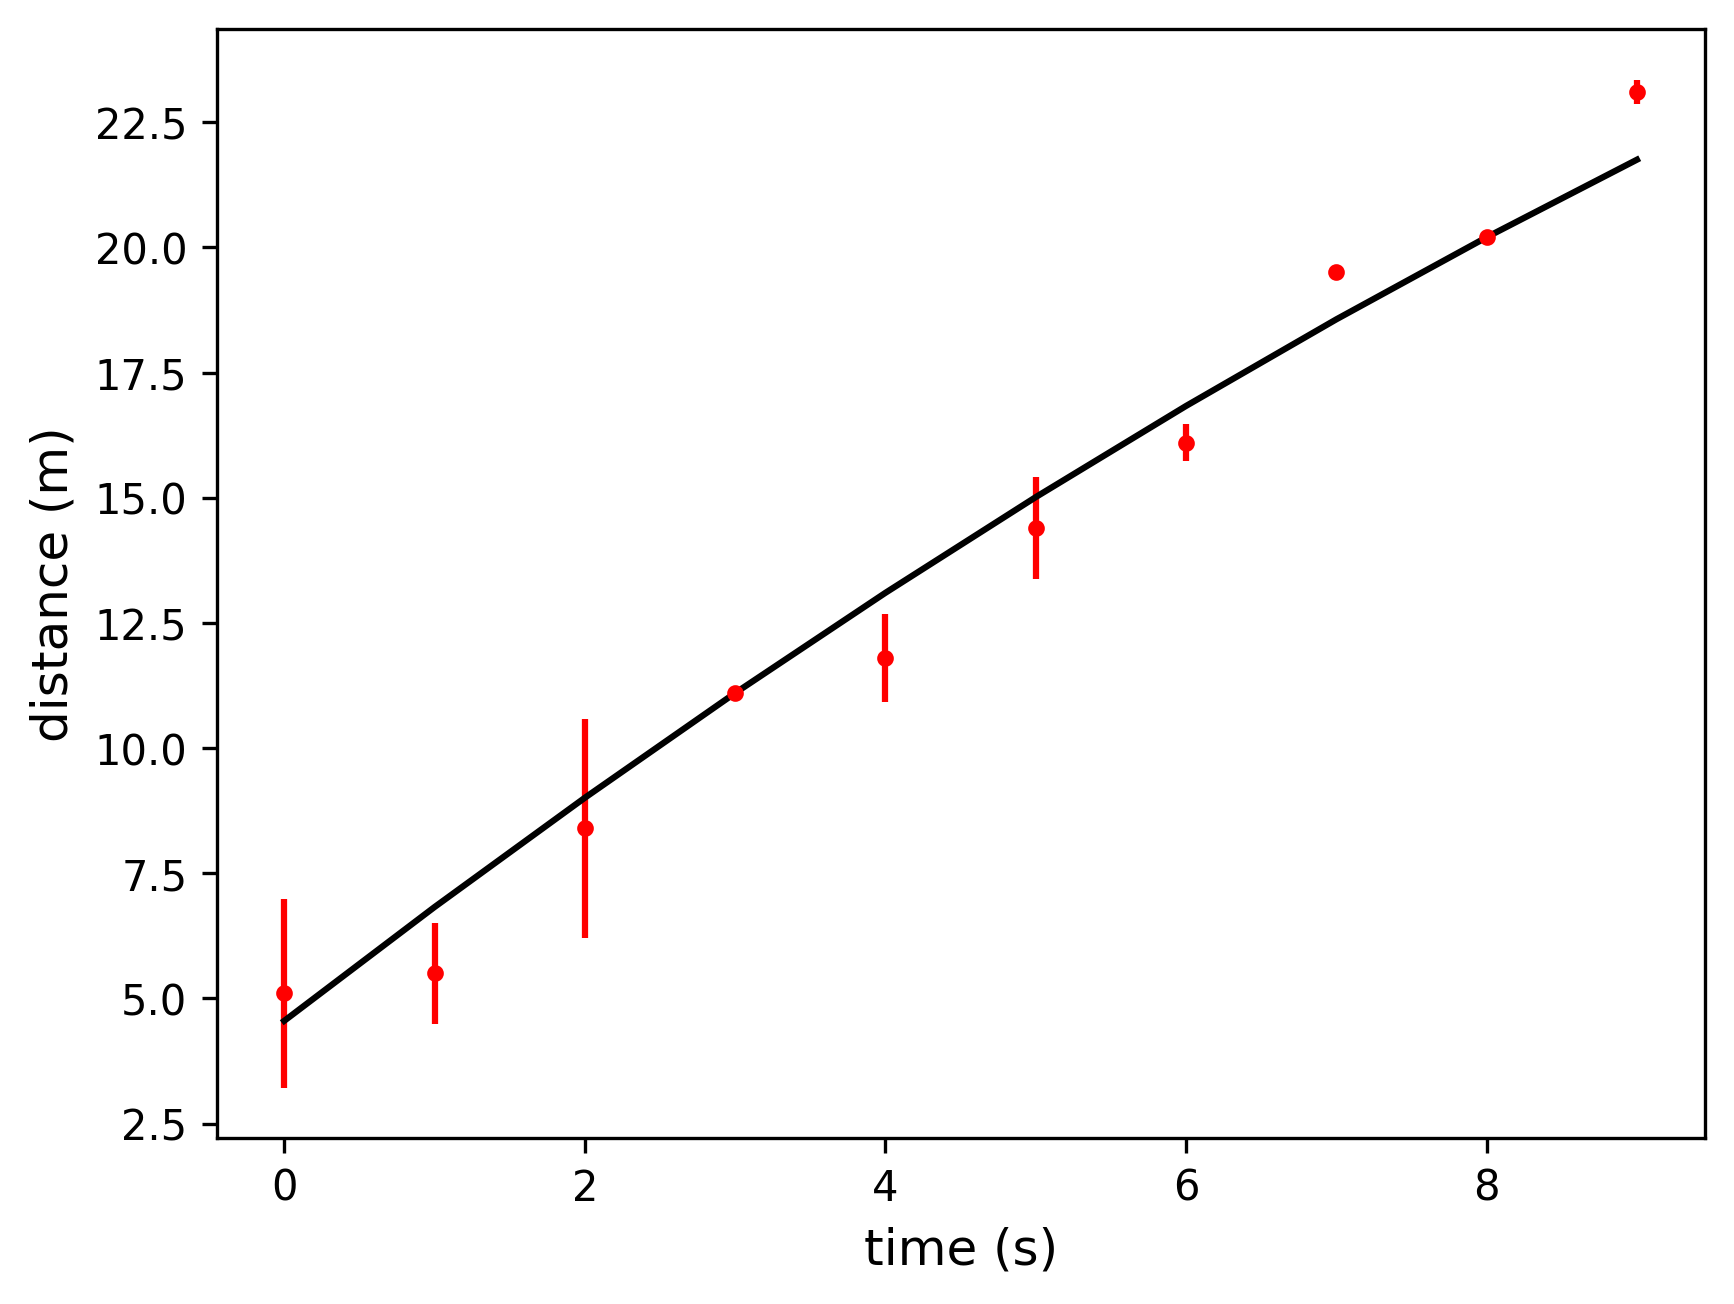

In [ ]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x,sin_func(x,*params) , c = 'black') #agregue sus parámetros